In [4]:
import pandas as pd

# Load the CSV
df = pd.read_csv('data/pubg.csv')

# Look at the first few rows
df.head()

,Unnamed: 0,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,2093518,a3e3cea9f2e314,c9f6eaa81245b5,a3d8693390584c,0,0,25.93,0,0,0,...,0,0.0,0,0.0,0,0,151.30,1,1525,0.0667
1,3701672,43e4be7ad72cc7,521836de101ee8,b65de9055327e0,0,0,36.71,0,0,0,...,0,0.0,0,0.0,0,0,1918.00,7,1516,0.5862
2,2059784,9a68690e31fdff,4a72ffa2cebd90,d6aad3f9830e60,0,1,47.73,0,0,0,...,0,4088.0,0,0.0,0,0,820.00,7,0,0.8105
3,1302036,b147e1bd448fc4,9a8991656b3fea,d931c0932d8aca,0,0,0.00,0,0,0,...,1,0.0,0,0.0,0,0,38.81,0,1515,0.5556
4,297180,d818b4edd59612,eece87c8b846b3,ec2b5ed94baae3,0,2,100.00,0,0,3,...,0,918.4,0,0.0,0,0,1721.00,5,0,0.6429


In [5]:
df = df.drop(['Id', 'groupId', 'matchId'], axis=1)
df = df.dropna()

In [6]:
df.columns

Index(['Unnamed: 0', 'assists', 'boosts', 'damageDealt', 'DBNOs',
       'headshotKills', 'heals', 'killPlace', 'killPoints', 'kills',
       'killStreaks', 'longestKill', 'matchDuration', 'matchType', 'maxPlace',
       'numGroups', 'rankPoints', 'revives', 'rideDistance', 'roadKills',
       'swimDistance', 'teamKills', 'vehicleDestroys', 'walkDistance',
       'weaponsAcquired', 'winPoints', 'winPlacePerc'],
      dtype='object')

In [8]:
df = df.drop(['Unnamed: 0'], axis=1)

In [9]:
target = 'winPlacePerc'

features = [
    'assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'heals',
    'killPlace', 'kills', 'killStreaks', 'longestKill', 'matchDuration',
    'numGroups', 'revives', 'rideDistance', 'roadKills', 'swimDistance',
    'teamKills', 'vehicleDestroys', 'walkDistance', 'weaponsAcquired'
]

X = df[features]
y = df[target]

In [11]:
print(X.info())


<class 'pandas.core.frame.DataFrame'>
Index: 1111741 entries, 0 to 1111741
Data columns (total 20 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   assists          1111741 non-null  int64  
 1   boosts           1111741 non-null  int64  
 2   damageDealt      1111741 non-null  float64
 3   DBNOs            1111741 non-null  int64  
 4   headshotKills    1111741 non-null  int64  
 5   heals            1111741 non-null  int64  
 6   killPlace        1111741 non-null  int64  
 7   kills            1111741 non-null  int64  
 8   killStreaks      1111741 non-null  int64  
 9   longestKill      1111741 non-null  float64
 10  matchDuration    1111741 non-null  int64  
 11  numGroups        1111741 non-null  int64  
 12  revives          1111741 non-null  int64  
 13  rideDistance     1111741 non-null  float64
 14  roadKills        1111741 non-null  int64  
 15  swimDistance     1111741 non-null  float64
 16  teamKills        111174

In [12]:
print(y.describe())

count    1.111741e+06
mean     4.727868e-01
std      3.073771e-01
min      0.000000e+00
25%      2.000000e-01
50%      4.583000e-01
75%      7.407000e-01
max      1.000000e+00
Name: winPlacePerc, dtype: float64


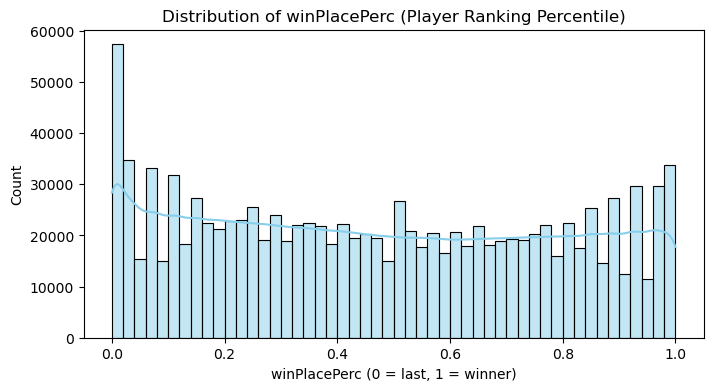

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(y, kde=True, bins=50, color='skyblue')
plt.title("Distribution of winPlacePerc (Player Ranking Percentile)")
plt.xlabel("winPlacePerc (0 = last, 1 = winner)")
plt.ylabel("Count")
plt.show()

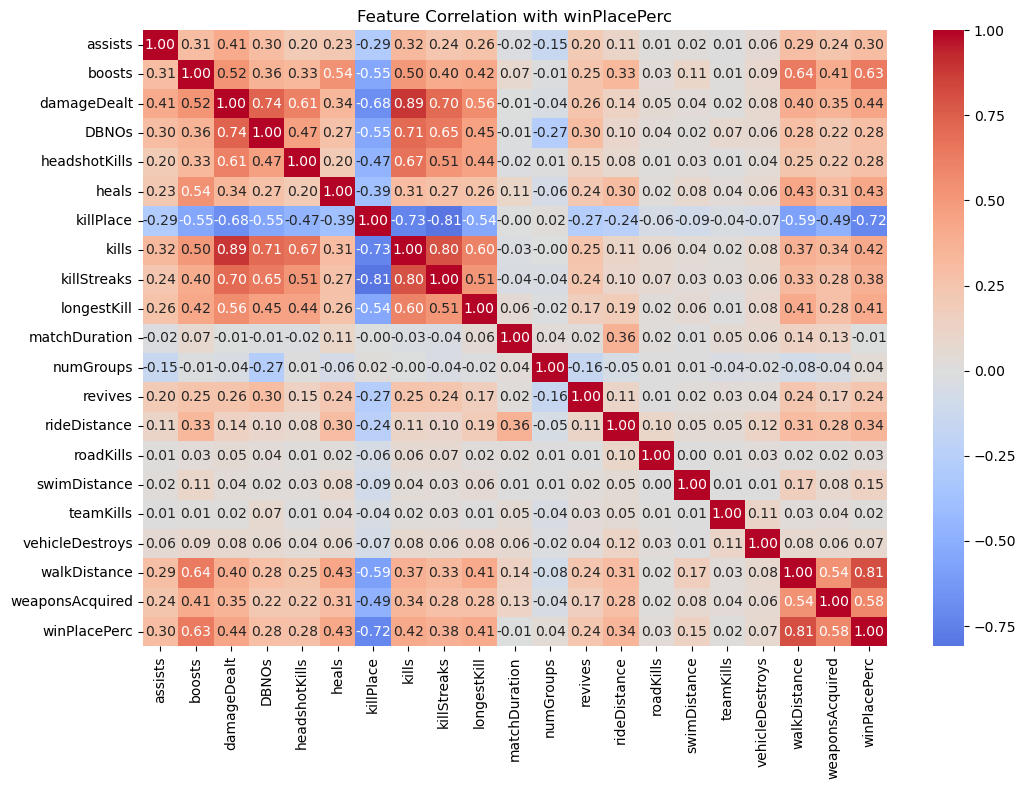

In [14]:
corr = df[features + [target]].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Feature Correlation with winPlacePerc")
plt.show()

In [15]:
corr

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,kills,killStreaks,longestKill,...,numGroups,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPlacePerc
assists,1.000000,0.306582,0.409369,0.302200,0.199487,0.228456,-0.289985,0.322067,0.243386,0.260407,...,-0.146553,0.197938,0.110496,0.012366,0.022871,0.007775,0.058241,0.288579,0.244594,0.297738
boosts,0.306582,1.000000,0.519600,0.357902,0.331536,0.535387,-0.554047,0.499478,0.403484,0.421444,...,-0.012530,0.254125,0.329281,0.033775,0.107880,0.014645,0.085997,0.639361,0.405301,0.633482
damageDealt,0.409369,0.519600,1.000000,0.735084,0.613306,0.341620,-0.676136,0.889038,0.703222,0.561656,...,-0.040571,0.256318,0.139840,0.050660,0.037509,0.016209,0.079900,0.396620,0.354514,0.438973
DBNOs,0.302200,0.357902,0.735084,1.000000,0.467393,0.265348,-0.554860,0.706211,0.646344,0.449521,...,-0.265377,0.301098,0.101882,0.035705,0.018726,0.071295,0.059857,0.284050,0.217667,0.279322
headshotKills,0.199487,0.331536,0.613306,0.467393,1.000000,0.197936,-0.468080,0.673739,0.513207,0.444803,...,0.008235,0.149131,0.076274,0.011974,0.029987,0.009198,0.039857,0.249591,0.215612,0.276170
heals,0.228456,0.535387,0.341620,0.265348,0.197936,1.000000,-0.385498,0.310537,0.268948,0.262337,...,-0.063574,0.236400,0.297734,0.023416,0.080991,0.035847,0.062720,0.429283,0.308228,0.427296
killPlace,-0.289985,-0.554047,-0.676136,-0.554860,-0.468080,-0.385498,1.000000,-0.728968,-0.809671,-0.539513,...,0.017791,-0.270057,-0.236372,-0.057496,-0.089924,-0.039589,-0.072698,-0.590132,-0.489745,-0.719051
kills,0.322067,0.499478,0.889038,0.706211,0.673739,0.310537,-0.728968,1.000000,0.802054,0.600461,...,-0.004645,0.253222,0.114664,0.061824,0.039986,0.019248,0.078644,0.373495,0.338190,0.418527
killStreaks,0.243386,0.403484,0.703222,0.646344,0.513207,0.268948,-0.809671,0.802054,1.000000,0.512811,...,-0.035947,0.241888,0.098000,0.065413,0.034264,0.030051,0.062696,0.326997,0.275110,0.376840
longestKill,0.260407,0.421444,0.561656,0.449521,0.444803,0.262337,-0.539513,0.600461,0.512811,1.000000,...,-0.017731,0.170472,0.190633,0.023292,0.055976,0.008853,0.082678,0.413090,0.275920,0.408853


In [18]:
corr_target = corr['winPlacePerc'].drop('winPlacePerc').sort_values(ascending=False)
print("Top correlated features with winPlacePerc:")
print(corr_target.head(10))

Top correlated features with winPlacePerc:
walkDistance       0.810817
boosts             0.633482
weaponsAcquired    0.582505
damageDealt        0.438973
heals              0.427296
kills              0.418527
longestKill        0.408853
killStreaks        0.376840
rideDistance       0.343015
assists            0.297738
Name: winPlacePerc, dtype: float64


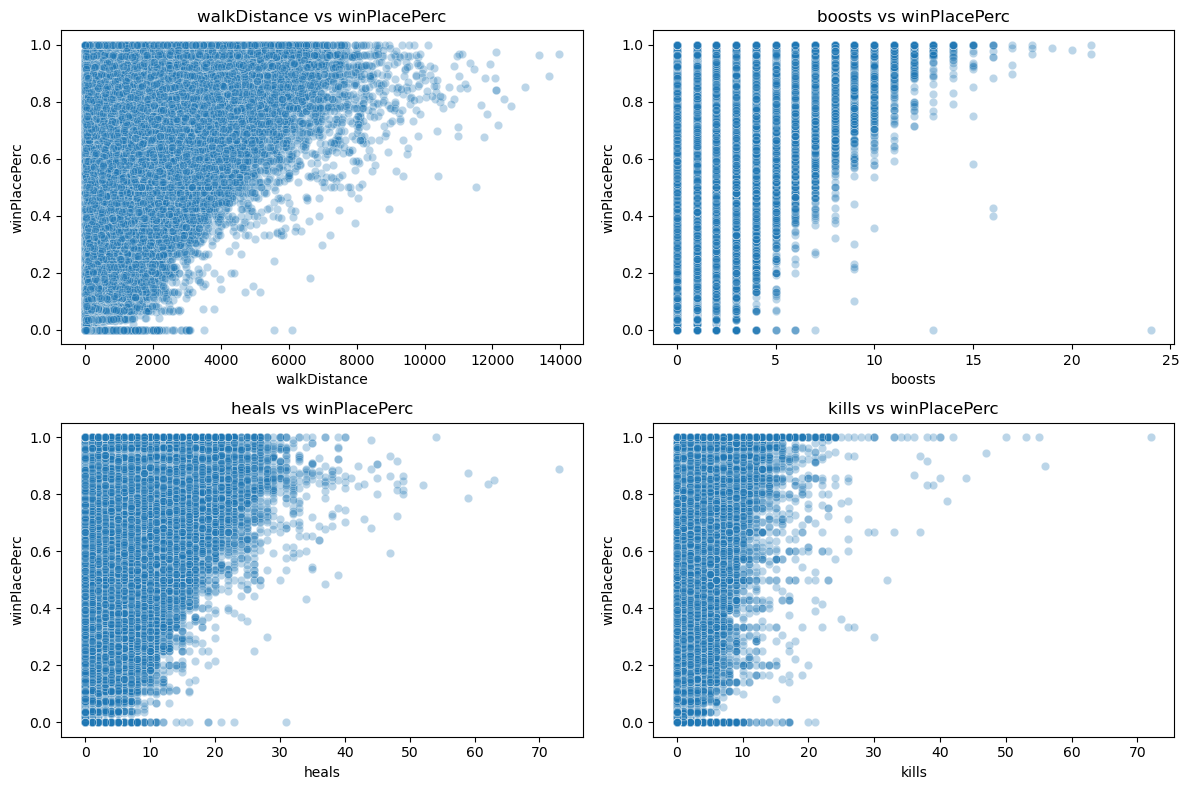

In [19]:
top_features = ['walkDistance', 'boosts', 'heals', 'kills']

plt.figure(figsize=(12,8))
for i, col in enumerate(top_features):
    plt.subplot(2,2,i+1)
    sns.scatterplot(x=df[col], y=y, alpha=0.3)
    plt.title(f"{col} vs winPlacePerc")
plt.tight_layout()
plt.show()

In [20]:
selected_features = [
    'walkDistance', 'boosts', 'weaponsAcquired', 'damageDealt', 'heals',
    'kills', 'rideDistance', 'longestKill', 'DBNOs', 'killPlace'
]

In [21]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [22]:
X = df[selected_features]
y = df['winPlacePerc']

In [23]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
}

In [27]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')
    print(f"{name}: Mean R² = {scores.mean():.4f} ± {scores.std():.4f}")

Linear Regression: Mean R² = 0.7832 ± 0.0007


KeyboardInterrupt: 

In [25]:
final_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
final_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
import joblib
joblib.dump(final_model, 'models/pubg_winplace_model.pkl')
print("✅ PUBG model saved successfully!")

✅ PUBG model saved successfully!
